# Модуль 1 — Модель расчёта суточной нормы КБЖУ
Генерируем датасет на основе формулы Миффлина, обучаем Random Forest Regressor
который предсказывает суточную норму калорий, белков, жиров и углеводов.

## Часть 1 — Генерация датасета

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N = 10000  # количество профилей

# Генерируем случайные профили людей
genders = np.random.choice(['female', 'male'], size=N)
ages    = np.random.randint(16, 65, size=N)
heights = np.where(genders == 'female',
                   np.random.randint(150, 180, size=N),
                   np.random.randint(165, 195, size=N))
weights = np.where(genders == 'female',
                   np.random.randint(45, 90, size=N),
                   np.random.randint(60, 110, size=N))

# Целевой вес — от -15кг до +15кг от текущего
target_weights = weights + np.random.randint(-15, 16, size=N)
target_weights = np.clip(target_weights, 40, 120)  # не меньше 40 и не больше 120

# Уровень активности
activity_levels = np.random.choice(
    ['sedentary', 'light', 'moderate', 'active'],
    size=N,
    p=[0.2, 0.3, 0.35, 0.15]
)

# Срок достижения цели в днях (30 до 365)
goal_days = np.random.randint(30, 366, size=N)

print('Профили сгенерированы:', N)
print('Пример — пол:', genders[:3], 'возраст:', ages[:3], 'вес:', weights[:3])

Профили сгенерированы: 10000
Пример — пол: ['female' 'male' 'female'] возраст: [55 22 47] вес: [54 83 67]


In [17]:
# Коэффициенты активности
ACTIVITY_COEFFICIENTS = {
    'sedentary': 1.2,
    'light':     1.375,
    'moderate':  1.55,
    'active':    1.725
}

def calculate_kbzhu(gender, age, height, weight, target_weight, activity, goal_days):
    """
    Считаем суточную норму КБЖУ по формуле Миффлина.
    Возвращает: calories, protein, fat, carbs
    """
    # Шаг 1 — Базовый обмен веществ (БОВ)
    if gender == 'female':
        bmr = (10 * weight) + (6.25 * height) - (5 * age) - 161
    else:
        bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5

    # Шаг 2 — Норма поддержания с учётом активности
    coef = ACTIVITY_COEFFICIENTS[activity]
    maintenance = bmr * coef

    # Шаг 3 — Корректируем на цель
    weight_diff = target_weight - weight  # положительное = набор, отрицательное = похудение
    # 1кг жира = ~7700 ккал, делим на количество дней
    daily_adjustment = (weight_diff * 7700) / goal_days
    # Ограничиваем корректировку — не более ±500 ккал в день (безопасно)
    daily_adjustment = np.clip(daily_adjustment, -500, 500)

    calories = maintenance + daily_adjustment
    calories = max(calories, 1200)  # минимум 1200 ккал для безопасности

    # Шаг 4 — Считаем БЖУ
    # Белок: 2г на кг тела (для набора массы важен белок)
    protein = weight * 2.0 if weight_diff > 0 else weight * 1.5
    # Жиры: 25% от калорий
    fat = (calories * 0.25) / 9  # 1г жира = 9 ккал
    # Углеводы: остаток калорий
    carbs = (calories - (protein * 4) - (fat * 9)) / 4  # 1г белка/углевода = 4 ккал
    carbs = max(carbs, 50)  # минимум 50г углеводов

    return round(calories, 1), round(protein, 1), round(fat, 1), round(carbs, 1)

# Считаем КБЖУ для всех профилей
results = [calculate_kbzhu(g, a, h, w, tw, act, gd)
           for g, a, h, w, tw, act, gd
           in zip(genders, ages, heights, weights, target_weights, activity_levels, goal_days)]

calories_list, protein_list, fat_list, carbs_list = zip(*results)

print('КБЖУ посчитаны для всех профилей')
print('Пример — калории:', calories_list[:3])

КБЖУ посчитаны для всех профилей
Пример — калории: (1200, np.float64(2838.1), np.float64(2523.1))


In [18]:
# Собираем датасет
df = pd.DataFrame({
    'gender':        genders,
    'age':           ages,
    'height':        heights,
    'weight':        weights,
    'target_weight': target_weights,
    'activity':      activity_levels,
    'goal_days':     goal_days,
    'calories':      calories_list,
    'protein':       protein_list,
    'fat':           fat_list,
    'carbs':         carbs_list
})

print('Датасет создан:', df.shape)
print()
print(df.head(5))

Датасет создан: (10000, 11)

   gender  age  height  weight  target_weight   activity  goal_days  calories  \
0  female   55     162      54             48  sedentary         86    1200.0   
1    male   22     190      83             80   moderate        183    2838.1   
2  female   47     165      67             79   moderate         54    2523.1   
3  female   63     151      45             40   moderate        300    1294.2   
4  female   34     167      77             68   moderate        231    1998.3   

   protein   fat  carbs  
0     81.0  33.3  144.0  
1    124.5  78.8  407.7  
2    134.0  70.1  339.1  
3     67.5  35.9  175.2  
4    115.5  55.5  259.2  


## Часть 2 — Подготовка данных

In [19]:
# Кодируем текстовые поля в числа
# gender: female=0, male=1
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

# activity: sedentary=0, light=1, moderate=2, active=3
activity_order = {'sedentary': 0, 'light': 1, 'moderate': 2, 'active': 3}
df['activity_encoded'] = df['activity'].map(activity_order)

# Добавляем разницу весов как отдельный признак
df['weight_diff'] = df['target_weight'] - df['weight']

print('Кодирование выполнено')
print(df[['gender','gender_encoded','activity','activity_encoded','weight_diff']].head(5))

Кодирование выполнено
   gender  gender_encoded   activity  activity_encoded  weight_diff
0  female               0  sedentary                 0           -6
1    male               1   moderate                 2           -3
2  female               0   moderate                 2           12
3  female               0   moderate                 2           -5
4  female               0   moderate                 2           -9


## Часть 3 — Обучение модели

In [20]:
# Признаки (входные данные)
FEATURES = ['gender_encoded', 'age', 'height', 'weight',
            'weight_diff', 'activity_encoded', 'goal_days']

# Целевые переменные (что предсказываем)
TARGETS = ['calories', 'protein', 'fat', 'carbs']

X = df[FEATURES]
y = df[TARGETS]

# Делим на train и test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train размер:', X_train.shape)
print('Test размер:', X_test.shape)

# Обучаем Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print()
print('Модель обучена')

Train размер: (8000, 7)
Test размер: (2000, 7)

Модель обучена


## Часть 4 — Оценка модели

In [21]:
y_pred = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=TARGETS)

print('Метрики модели')
print()
for col in TARGETS:
    mae = mean_absolute_error(y_test[col], y_pred_df[col])
    r2  = r2_score(y_test[col], y_pred_df[col])
    print(f'{col}:')
    print(f'  MAE (средняя ошибка): {mae:.2f}')
    print(f'  R² (точность модели): {r2:.4f}')
    print()

Метрики модели

calories:
  MAE (средняя ошибка): 70.19
  R² (точность модели): 0.9771

protein:
  MAE (средняя ошибка): 4.58
  R² (точность модели): 0.9654

fat:
  MAE (средняя ошибка): 1.95
  R² (точность модели): 0.9771

carbs:
  MAE (средняя ошибка): 12.76
  R² (точность модели): 0.9664



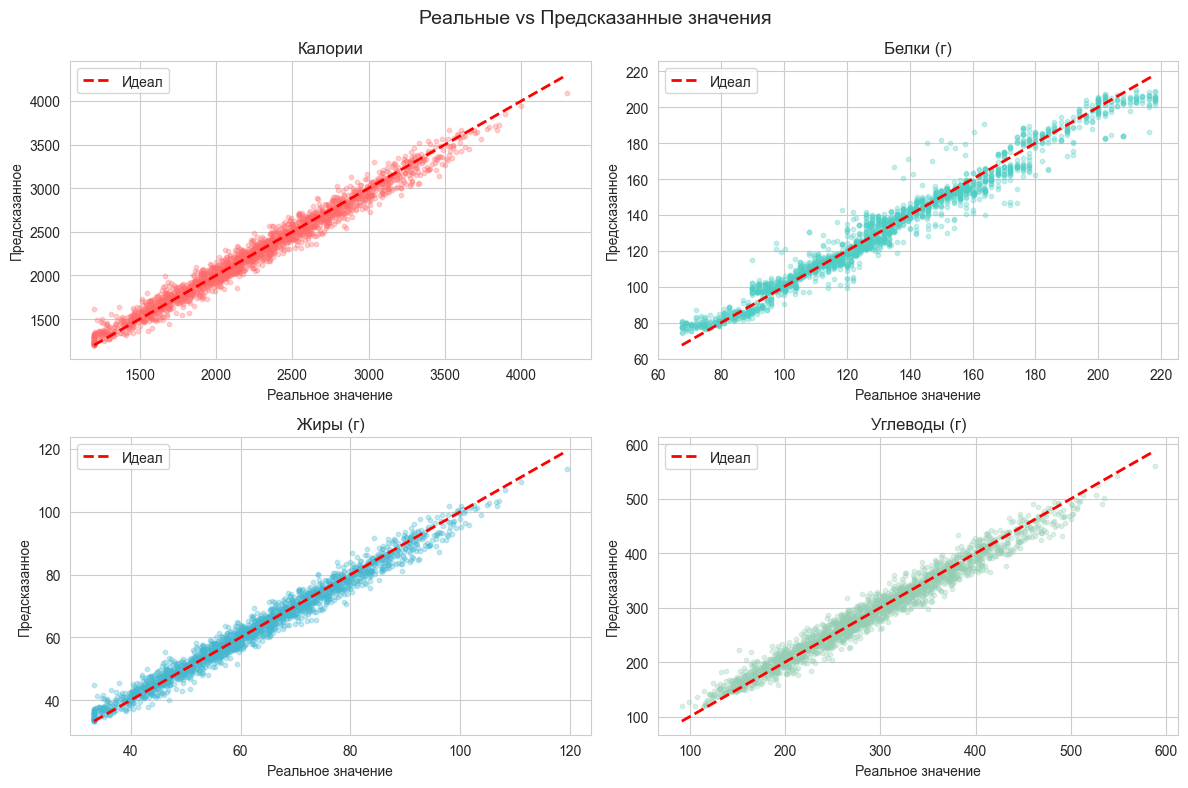

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Реальные vs Предсказанные значения', fontsize=14)

titles = ['Калории', 'Белки (г)', 'Жиры (г)', 'Углеводы (г)']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for ax, col, title, color in zip(axes.flat, TARGETS, titles, colors):
    ax.scatter(y_test[col], y_pred_df[col], alpha=0.3, color=color, s=10)
    # Идеальная линия
    min_val = min(y_test[col].min(), y_pred_df[col].min())
    max_val = max(y_test[col].max(), y_pred_df[col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеал')
    ax.set_title(title)
    ax.set_xlabel('Реальное значение')
    ax.set_ylabel('Предсказанное')
    ax.legend()

plt.tight_layout()
plt.show()

## Часть 5 — Логика необязательных полей

In [23]:
def suggest_goal_days(current_weight, target_weight):
    """
    Если пользователь не указал срок — предлагаем безопасный срок.
    Набор: 0.4кг в неделю. Похудение: 0.7кг в неделю.
    """
    diff = abs(target_weight - current_weight)
    if diff == 0:
        return 90  # поддержание — 3 месяца
    elif target_weight > current_weight:
        weeks = diff / 0.4  # набор массы — медленнее
    else:
        weeks = diff / 0.7  # похудение — чуть быстрее
    days = int(weeks * 7)
    return max(days, 30)  # минимум 30 дней


def predict_kbzhu(gender, age, height, weight, target_weight,
                  activity='moderate', goal_days=None,
                  wake_time='08:00', sleep_time='23:00'):
    """
    Главная функция предсказания КБЖУ.
    Обязательные: gender, age, height, weight, target_weight
    Необязательные: activity, goal_days, wake_time, sleep_time
    """
    # Если срок не указан — предлагаем сами
    suggested = False
    if goal_days is None:
        goal_days = suggest_goal_days(weight, target_weight)
        suggested = True

    # Кодируем входные данные
    gender_enc    = 0 if gender == 'female' else 1
    activity_enc  = activity_order[activity]
    weight_diff   = target_weight - weight

    # Предсказываем
    X_input = pd.DataFrame([{
        'gender_encoded':   gender_enc,
        'age':              age,
        'height':           height,
        'weight':           weight,
        'weight_diff':      weight_diff,
        'activity_encoded': activity_enc,
        'goal_days':        goal_days
    }])

    pred = model.predict(X_input)[0]

    result = {
        'calories':   round(pred[0]),
        'protein':    round(pred[1]),
        'fat':        round(pred[2]),
        'carbs':      round(pred[3]),
        'goal_days':  goal_days,
        'suggested_days': suggested,
        'wake_time':  wake_time,
        'sleep_time': sleep_time
    }
    return result


# Тест — девушка 20 лет, 47кг, 157см, хочет 50кг
result = predict_kbzhu(
    gender='female',
    age=20,
    height=157,
    weight=47,
    target_weight=50
    # activity и goal_days не указываем — модель предложит сама
)

print('Результат для тестового профиля')
print(f'Суточные калории:  {result["calories"]} ккал')
print(f'Белки:             {result["protein"]} г')
print(f'Жиры:              {result["fat"]} г')
print(f'Углеводы:          {result["carbs"]} г')
print(f'Срок достижения:   {result["goal_days"]} дней', '(предложен моделью)' if result['suggested_days'] else '')

Результат для тестового профиля
Суточные калории:  2242 ккал
Белки:             99 г
Жиры:              62 г
Углеводы:          321 г
Срок достижения:   52 дней (предложен моделью)


## Часть 6 — Сохранение модели

In [24]:
# Сохраняем модель и энкодеры
model_data = {
    'model':          model,
    'features':       FEATURES,
    'targets':        TARGETS,
    'activity_order': activity_order,
    'le_gender':      le_gender
}

with open('../models/kbzhu_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('Модель сохранена: models/kbzhu_model.pkl')

# Проверяем — загружаем обратно и тестируем
with open('../models/kbzhu_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

print('Модель успешно загружена обратно!')
print('Признаки:', loaded['features'])

Модель сохранена: models/kbzhu_model.pkl
Модель успешно загружена обратно!
Признаки: ['gender_encoded', 'age', 'height', 'weight', 'weight_diff', 'activity_encoded', 'goal_days']
